# 03 — Entertainment Content Strategy: Data Understanding (EDA)

**Pregunta de negocio:** ¿qué tipo de contenido debería adquirir o producir la plataforma para maximizar engagement, e identificar brechas de catálogo por género/país/rating?

Este notebook cubre la fase **Data Understanding**: nulos, outliers, cardinalidad y — la pregunta más importante de este dataset en particular — **qué se puede y qué no se puede responder** con la metadata disponible.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

DATA_PATH = '../data/netflix_titles.csv'

## 1. Carga de datos

In [2]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head(3)

(8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


## 2. Estructura y tipos

| Columna | Significado |
|---|---|
| `type` | Movie / TV Show |
| `director`, `cast` | texto libre, multivaluado (separado por comas) |
| `country` | multivaluado — un título puede tener varios países de producción |
| `date_added` | fecha en que el título se incorporó al catálogo de Netflix |
| `release_year` | año de producción original |
| `rating` | clasificación por edad (TV-MA, PG-13, etc.) |
| `duration` | minutos (películas) o temporadas (series) — **unidades distintas según `type`** |
| `listed_in` | géneros, multivaluado |
| `description` | sinopsis en texto libre |

In [3]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

## 3. Nulos

In [4]:
nulls = df.isnull().sum().sort_values(ascending=False)
nulls_pct = (nulls / len(df) * 100).round(1)
pd.DataFrame({'nulos': nulls, '% del total': nulls_pct})

,nulos,% del total
director,2634,29.9
country,831,9.4
cast,825,9.4
date_added,10,0.1
rating,4,0.0
duration,3,0.0
show_id,0,0.0
type,0,0.0
title,0,0.0
release_year,0,0.0


`director` tiene 29.9% de nulos y `cast` 9.4% — en Netflix, es común que documentales, stand-up specials o producciones internacionales no tengan esos campos cargados; no es necesariamente un error de captura. **Decisión para Data Preparation:** tratar estos nulos como categoría `"Desconocido"` en vez de eliminar filas — perder ~30% de las películas por un nulo en `director` destruiría el análisis de catálogo.

## 4. Duplicados

In [5]:
print('Filas duplicadas exactas:', df.duplicated().sum())
print('Títulos duplicados (mismo `title`, distinto show_id):', df['title'].duplicated().sum())

Filas duplicadas exactas: 0
Títulos duplicados (mismo `title`, distinto show_id): 0


## 5. Bug de calidad de datos: valores de `duration` filtrados en `rating`

In [6]:
bad_rating = df[df['rating'].astype(str).str.contains('min', na=False)]
bad_rating[['show_id', 'type', 'title', 'rating', 'duration']]

,show_id,type,title,rating,duration
5541,s5542,Movie,Louis C.K. 2017,74 min,NaN
5794,s5795,Movie,Louis C.K.: Hilarious,84 min,NaN
5813,s5814,Movie,Louis C.K.: Live at the Comedy Store,66 min,NaN


**Hallazgo:** 3 filas tienen un valor de duración (`"74 min"`, etc.) metido en la columna `rating`, y `duration` queda nulo para esas mismas filas — un corrimiento de columna en el CSV original, no una categoría de rating real. **Decisión para Data Preparation:** mover el valor a `duration` y marcar `rating` como desconocido en esas 3 filas.

## 6. Cardinalidad

In [7]:
print('type:', df['type'].nunique(), df['type'].unique().tolist())
print('rating (incluye las 3 filas con el bug):', df['rating'].nunique())
print('release_year:', df['release_year'].nunique(), f"({df['release_year'].min()}-{df['release_year'].max()})")
print()
print('country — combinaciones únicas como string:', df['country'].nunique())
countries_exploded = df['country'].dropna().str.split(', ').explode()
print('country — países individuales tras separar:', countries_exploded.nunique())
print()
print('listed_in — combinaciones únicas como string:', df['listed_in'].nunique())
genres_exploded = df['listed_in'].str.split(', ').explode()
print('listed_in — géneros individuales tras separar:', genres_exploded.nunique())
print()
print('director — valores únicos (no nulos):', df['director'].nunique())
print('cast — valores únicos (no nulos):', df['cast'].nunique())

type: 2 ['Movie', 'TV Show']
rating (incluye las 3 filas con el bug): 17
release_year: 74 (1925-2021)

country — combinaciones únicas como string: 748
country — países individuales tras separar: 127

listed_in — combinaciones únicas como string: 514
listed_in — géneros individuales tras separar: 42

director — valores únicos (no nulos): 4528
cast — valores únicos (no nulos): 7692


**`country` y `listed_in` son multivaluados** (un título puede tener varios países o géneros, separados por coma). Para cualquier análisis de brechas por país o género hay que *explotar* estas columnas — pero contar filas explotadas como si fueran títulos infla el total (un título con 3 países cuenta 3 veces). Se documenta para no cometer ese error en el análisis descriptivo. `director` y `cast` tienen cardinalidad altísima y dispersa — no son buenas variables categóricas para agrupar directamente.

## 7. Movies vs. TV Shows

type
Movie      6131
TV Show    2676
Name: count, dtype: int64
type
Movie      69.6
TV Show    30.4
Name: count, dtype: float64


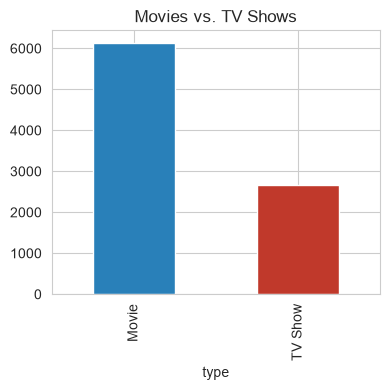

In [8]:
type_counts = df['type'].value_counts()
print(type_counts)
print((type_counts / len(df) * 100).round(1))

fig, ax = plt.subplots(figsize=(4, 4))
type_counts.plot(kind='bar', ax=ax, color=['#2980b9', '#c0392b'])
ax.set_title('Movies vs. TV Shows')
plt.tight_layout()
plt.show()

69.6% películas, 30.4% series — el catálogo está claramente sesgado hacia películas.

## 8. `duration`: unidades distintas por tipo — no se pueden comparar directamente

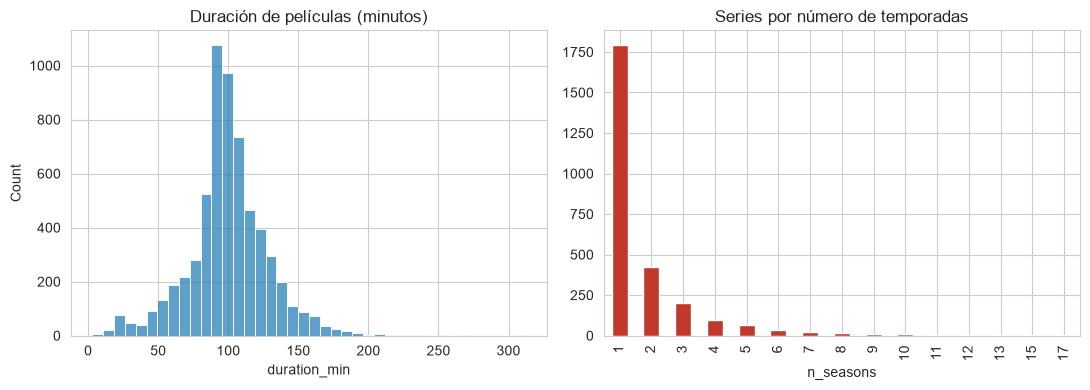

Duración de películas — describe:
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

% de series con 1 sola temporada: 67.0%


In [9]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = pd.to_numeric(movies['duration'].str.replace(' min', '', regex=False), errors='coerce')

shows = df[df['type'] == 'TV Show'].copy()
shows['n_seasons'] = pd.to_numeric(shows['duration'].str.extract(r'(\d+)')[0], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(movies['duration_min'].dropna(), bins=40, ax=axes[0], color='#2980b9')
axes[0].set_title('Duración de películas (minutos)')

shows['n_seasons'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#c0392b')
axes[1].set_title('Series por número de temporadas')
plt.tight_layout()
plt.show()

print('Duración de películas — describe:')
print(movies['duration_min'].describe())
print()
print(f"% de series con 1 sola temporada: {(shows['n_seasons'] == 1).mean():.1%}")

La gran mayoría de las series tienen una sola temporada — consistente con que Netflix incorpora mucho contenido de terceros que no necesariamente renueva.

## 9. `date_added`: cuándo se incorporó el contenido al catálogo

Filas sin date_added parseable: 10 de 8807
Rango: 2008-01-01 00:00:00 -> 2021-09-25 00:00:00


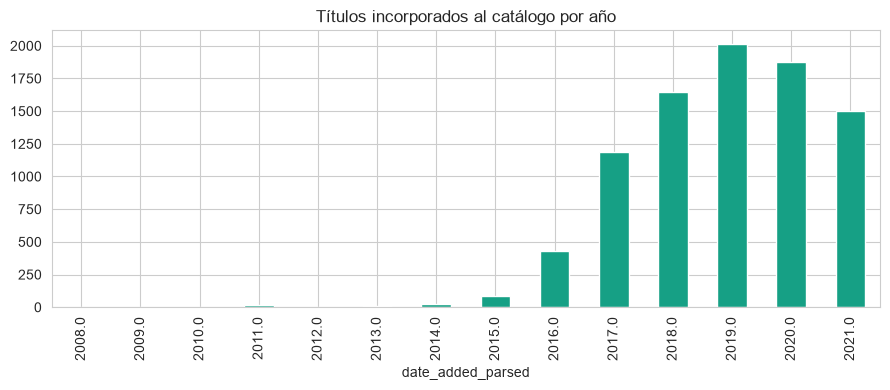

In [10]:
df['date_added_parsed'] = pd.to_datetime(df['date_added'].str.strip(), format='%B %d, %Y', errors='coerce')
print('Filas sin date_added parseable:', df['date_added_parsed'].isnull().sum(), 'de', len(df))
print('Rango:', df['date_added_parsed'].min(), '->', df['date_added_parsed'].max())

additions_by_year = df['date_added_parsed'].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
additions_by_year.plot(kind='bar', ax=ax, color='#16a085')
ax.set_title('Títulos incorporados al catálogo por año')
plt.tight_layout()
plt.show()

El catálogo creció fuertemente entre 2018 y 2020, con una caída notoria en 2021 (el dataset probablemente no cubre el año completo — el máximo de `date_added` es un buen chequeo de hasta cuándo llega realmente el dato).

## 10. Brechas de catálogo: país y género

Usando las columnas explotadas (sección 6), con la salvedad de que un título puede aparecer en varias barras.

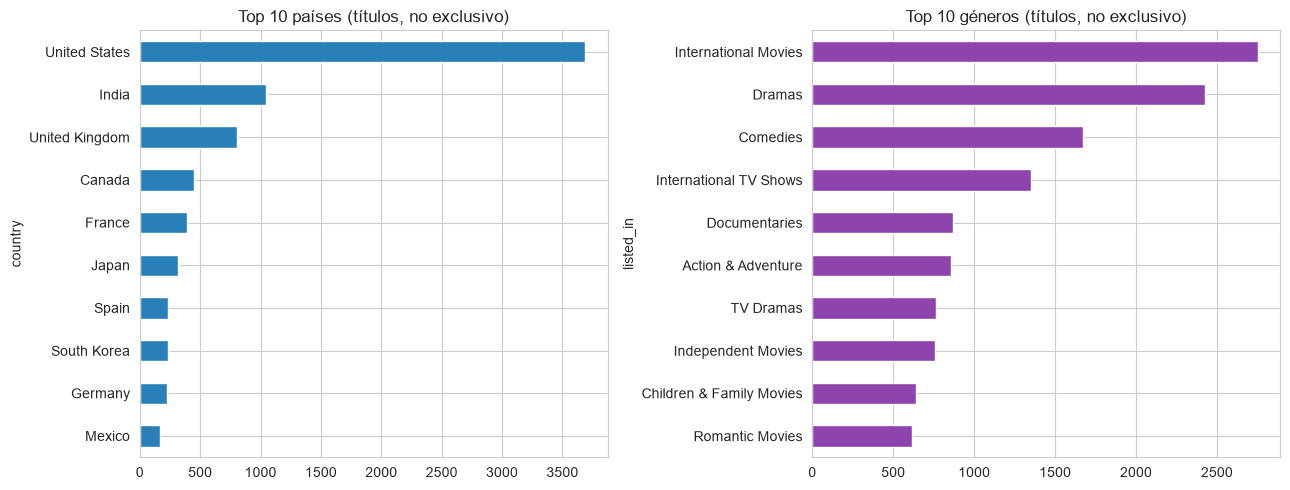

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

countries_exploded.value_counts().head(10).sort_values().plot(kind='barh', ax=axes[0], color='#2980b9')
axes[0].set_title('Top 10 países (títulos, no exclusivo)')

genres_exploded.value_counts().head(10).sort_values().plot(kind='barh', ax=axes[1], color='#8e44ad')
axes[1].set_title('Top 10 géneros (títulos, no exclusivo)')

plt.tight_layout()
plt.show()

**Concentración fuerte:** Estados Unidos domina el catálogo (3.689 títulos, sobre un total de 8.807 — más de 4 de cada 10 títulos incluyen EE. UU. como país), India es un distante segundo. En géneros, "International Movies" y "Dramas" concentran la mayor parte. Esto ya sugiere una hipótesis de negocio (brecha en mercados no anglófonos fuera de India) que se retoma en el análisis descriptivo completo del dashboard.

## 11. La pregunta que este dataset NO puede responder directamente

El objetivo de negocio original habla de "maximizar *engagement*" y predecir "probabilidad de éxito". **Este dataset no trae ninguna métrica de audiencia:** no hay vistas, no hay rating de usuarios, no hay tiempo de reproducción, no hay retención. Es pura metadata de catálogo (qué existe), no de consumo (qué se mira).

Esto no es un detalle menor — es la limitación central del proyecto, y cambia el alcance real de lo que se puede construir:

- **Sí es posible:** un análisis de brechas de catálogo (qué está sobre- o sub-representado por género/país/rating/año) y un sistema de recomendación *content-based* (similitud entre títulos por texto/género/reparto) — ninguno de los dos necesita una etiqueta de éxito.
- **Requiere un proxy, documentado como tal:** un modelo que "prediga probabilidad de éxito" necesita definir qué es "éxito" sin datos de audiencia. Cualquier proxy que se use en `02_data_preparation.ipynb` (por ejemplo, antigüedad en catálogo, o pertenecer a un género/país con alta concentración) es una aproximación débil y debe presentarse con esa advertencia explícita — no como una predicción real de éxito comercial.

## 12. Conclusiones de la fase de Data Understanding

1. **Sin duplicados exactos**, pero con nulos altos y esperables en `director` (29.9%) y `cast` (9.4%) — se tratan como categoría "Desconocido", no se eliminan filas.
2. **Bug de datos confirmado:** 3 filas con un valor de duración filtrado en `rating` — se corrige en Data Preparation.
3. **`country` y `listed_in` son multivaluados:** cualquier conteo por país/género debe explotar la columna y aclarar que los totales no sumarán al total de títulos.
4. **`duration` tiene unidades distintas según `type`** (minutos vs. temporadas) — no se puede tratar como una sola variable numérica sin separar por tipo primero.
5. **Concentración fuerte en EE. UU. y en pocos géneros** — primera hipótesis de brecha de catálogo para el análisis descriptivo.
6. **Limitación central del proyecto:** no hay métrica de audiencia/engagement en el dataset. El enfoque científico (recomendador content-based) es viable sin ella; el modelo de "probabilidad de éxito" requiere un proxy que se documentará explícitamente como una aproximación, no como una medición real de éxito comercial.

**Siguiente paso:** `02_data_preparation.ipynb` — corregir el bug de `rating`/`duration`, normalizar las columnas multivaluadas, y construir el proxy de "éxito" con sus limitaciones documentadas.